# DeepLOB on FI-2010 — Main Reproducible Report

This notebook is the **single report entry-point** for the FI-2010 workflow.
It does **not** retrain the model by default. Instead, it loads artifacts generated by the cluster scripts and presents:

1. The original **Conv + Inception + LSTM** DeepLOB pipeline  
2. Training curves and multi-horizon classification results  
3. The added **144-row engineered-feature statistical analysis** (u2–u9 feature families)  
4. Qualified factor selection, baseline models, and comparison with DeepLOB  
5. Trading-signal / strategy-style statistical evaluation  

> Heavy work is delegated to scripts:
> - `submit_deeplob.sh` → GPU training
> - `submit_analysis.sh` → CPU feature-analysis / baseline artifact generation


## 1. Reproduction workflow

### Step 1 — Train DeepLOB on GPU
```bash
cd /ocean/projects/mth250011p/xxiao7/DeepLOB
sbatch submit_deeplob.sh
```

### Step 2 — Generate analysis artifacts on CPU
```bash
sbatch submit_analysis.sh
```

### Step 3 — Open this notebook and Run All
The notebook only loads saved outputs from `results/` and `models/` and performs lightweight formatting / display.

### Key files
| Path | Purpose |
|---|---|
| `scripts/train_deeplob.py` | 5-horizon DeepLOB GPU training |
| `scripts/analyze_fi2010.py` | feature tests, baseline models, strategy stats |
| `models/deeplob_k*.pt` | saved model checkpoints |
| `results/*.png`, `results/*.csv`, `results/*.npz` | report artifacts |


## 2. Setup

In [1]:
import sys, os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BASE_DIR = '/ocean/projects/mth250011p/xxiao7/DeepLOB'
DATA_DIR = os.path.join(BASE_DIR, 'data')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

print('BASE_DIR =', BASE_DIR)
print('Results dir exists:', os.path.exists(RESULT_DIR))


BASE_DIR = /ocean/projects/mth250011p/xxiao7/DeepLOB
Results dir exists: True


In [2]:
# Quick artifact status check
required = [
    'performance_summary.csv', 'all_results.pkl',
    'comparison_horizons.png', 'confidence_dist.png', 'all_cm_summary.png',
    'feature_nw_ttest.png', 'rolling_ttest.png', 'factor_monotonicity.png',
    'factor_rank_ic.png', 'qualified_monotonicity.png', 'trading_profit_ttest.png'
]
rows=[]
for name in required:
    path=os.path.join(RESULT_DIR,name)
    rows.append({'artifact':name, 'exists':os.path.exists(path)})
pd.DataFrame(rows)


,artifact,exists
0,performance_summary.csv,True
1,all_results.pkl,True
2,comparison_horizons.png,True
3,confidence_dist.png,True
4,all_cm_summary.png,True
5,feature_nw_ttest.png,True
6,rolling_ttest.png,True
7,factor_monotonicity.png,True
8,factor_rank_ic.png,True
9,qualified_monotonicity.png,True


## 3. Dataset and task

FI-2010 contains 149 rows per event:
- rows **0–39**: raw 10-level LOB features used by DeepLOB
- rows **40–143**: engineered features (u2–u9)
- rows **144–148**: labels for 5 prediction horizons

The main DeepLOB task is **3-class mid-price movement prediction** at horizons:
- k=1 → 10 events ahead
- k=2 → 20 events ahead
- k=3 → 30 events ahead
- k=4 → 50 events ahead
- k=5 → 100 events ahead


In [3]:
# Train / test sizes and label distribution
train_all = np.loadtxt(os.path.join(DATA_DIR, 'Train_Dst_NoAuction_DecPre_CF_7.txt'))
train = train_all[:, :int(np.floor(train_all.shape[1] * 0.8))]
val   = train_all[:, int(np.floor(train_all.shape[1] * 0.8)):]
t1 = np.loadtxt(os.path.join(DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_7.txt'))
t2 = np.loadtxt(os.path.join(DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_8.txt'))
t3 = np.loadtxt(os.path.join(DATA_DIR, 'Test_Dst_NoAuction_DecPre_CF_9.txt'))
test = np.hstack((t1, t2, t3))
print('Train:', train.shape, ' Val:', val.shape, ' Test:', test.shape)

for k_idx, k_name in enumerate(['k=1','k=2','k=3','k=4','k=5']):
    y = test[144 + k_idx] - 1
    vals, cnts = np.unique(y, return_counts=True)
    print(k_name, dict(zip(['Down','Stationary','Up'], cnts.tolist())))


Train: (149, 203800)  Val: (149, 50950)  Test: (149, 139587)
k=1 {'Down': 21167, 'Stationary': 98638, 'Up': 19782}
k=2 {'Down': 27470, 'Stationary': 86618, 'Up': 25499}
k=3 {'Down': 31941, 'Stationary': 78318, 'Up': 29328}
k=4 {'Down': 38467, 'Stationary': 66007, 'Up': 35113}
k=5 {'Down': 47976, 'Stationary': 48060, 'Up': 43551}


## 4. DeepLOB architecture

The reproduced primary model is exactly the paper's **Conv + Inception + LSTM** structure:

```
Input (B, 1, 100, 40)
  → Conv Block 1
  → Conv Block 2
  → Conv Block 3
  → Inception module
  → LSTM(hidden=64)
  → FC(3)
```

The three convolution blocks first aggregate price-volume information and order-book depth structure. The Inception block extracts multi-scale temporal patterns, and the LSTM models sequential dependence across the 100-event lookback window.


In [4]:
# Show the model definition from the training script (lightweight, no training)
from pathlib import Path
script = Path(BASE_DIR) / 'scripts' / 'train_deeplob.py'
text = script.read_text()
start = text.index('class DeepLOB')
end = text.index('def batch_gd(')
print(text[start:end].rstrip())


class DeepLOB(nn.Module):
    """DeepLOB: CNN + Inception + LSTM for LOB mid-price prediction.

    Architecture follows Zhang et al. (2019):
      Input (B, 1, T, 40) → 3 Conv blocks → Inception → LSTM → FC(3)
    """
    def __init__(self, y_len=3):
        super().__init__()
        self.y_len = y_len

        # Block 1 — price-volume level extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=(1, 2), stride=(1, 2)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.LeakyReLU(0.01), nn.BatchNorm2d(32),
        )
        # Block 2 — level aggregation
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.Tanh(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.Tanh(), nn.BatchNorm2d(3

## 5. Main DeepLOB results

In [5]:
perf = pd.read_csv(os.path.join(RESULT_DIR, 'performance_summary.csv'))
perf.style.format({c: '{:.4f}' for c in perf.columns if c != 'Horizon'})


,Horizon,Accuracy,Cohen κ,MCC,F1-Down,F1-Stat,F1-Up,F1-Weighted
0,k=1 (10 ev),0.8223,0.5653,0.5784,0.5992,0.8979,0.5908,0.8092
1,k=2 (20 ev),0.7192,0.4194,0.4374,0.4788,0.8270,0.4814,0.6954
2,k=3 (30 ev),0.7505,0.5552,0.5612,0.6141,0.8398,0.6169,0.7414
3,k=4 (50 ev),0.7486,0.6065,0.6068,0.6879,0.8238,0.6760,0.7492
4,k=5 (100 ev),0.7379,0.6067,0.6070,0.7160,0.7795,0.7151,0.7376


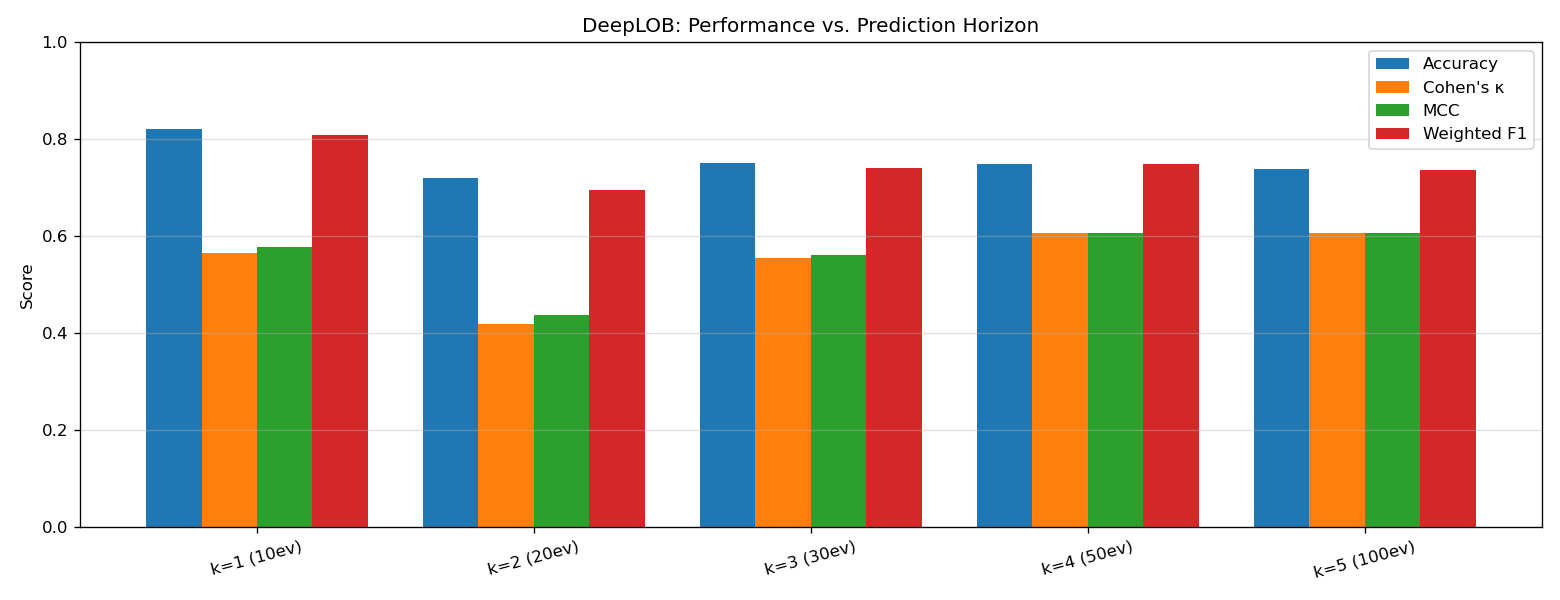

In [6]:
display(Image(os.path.join(RESULT_DIR, 'comparison_horizons.png')))


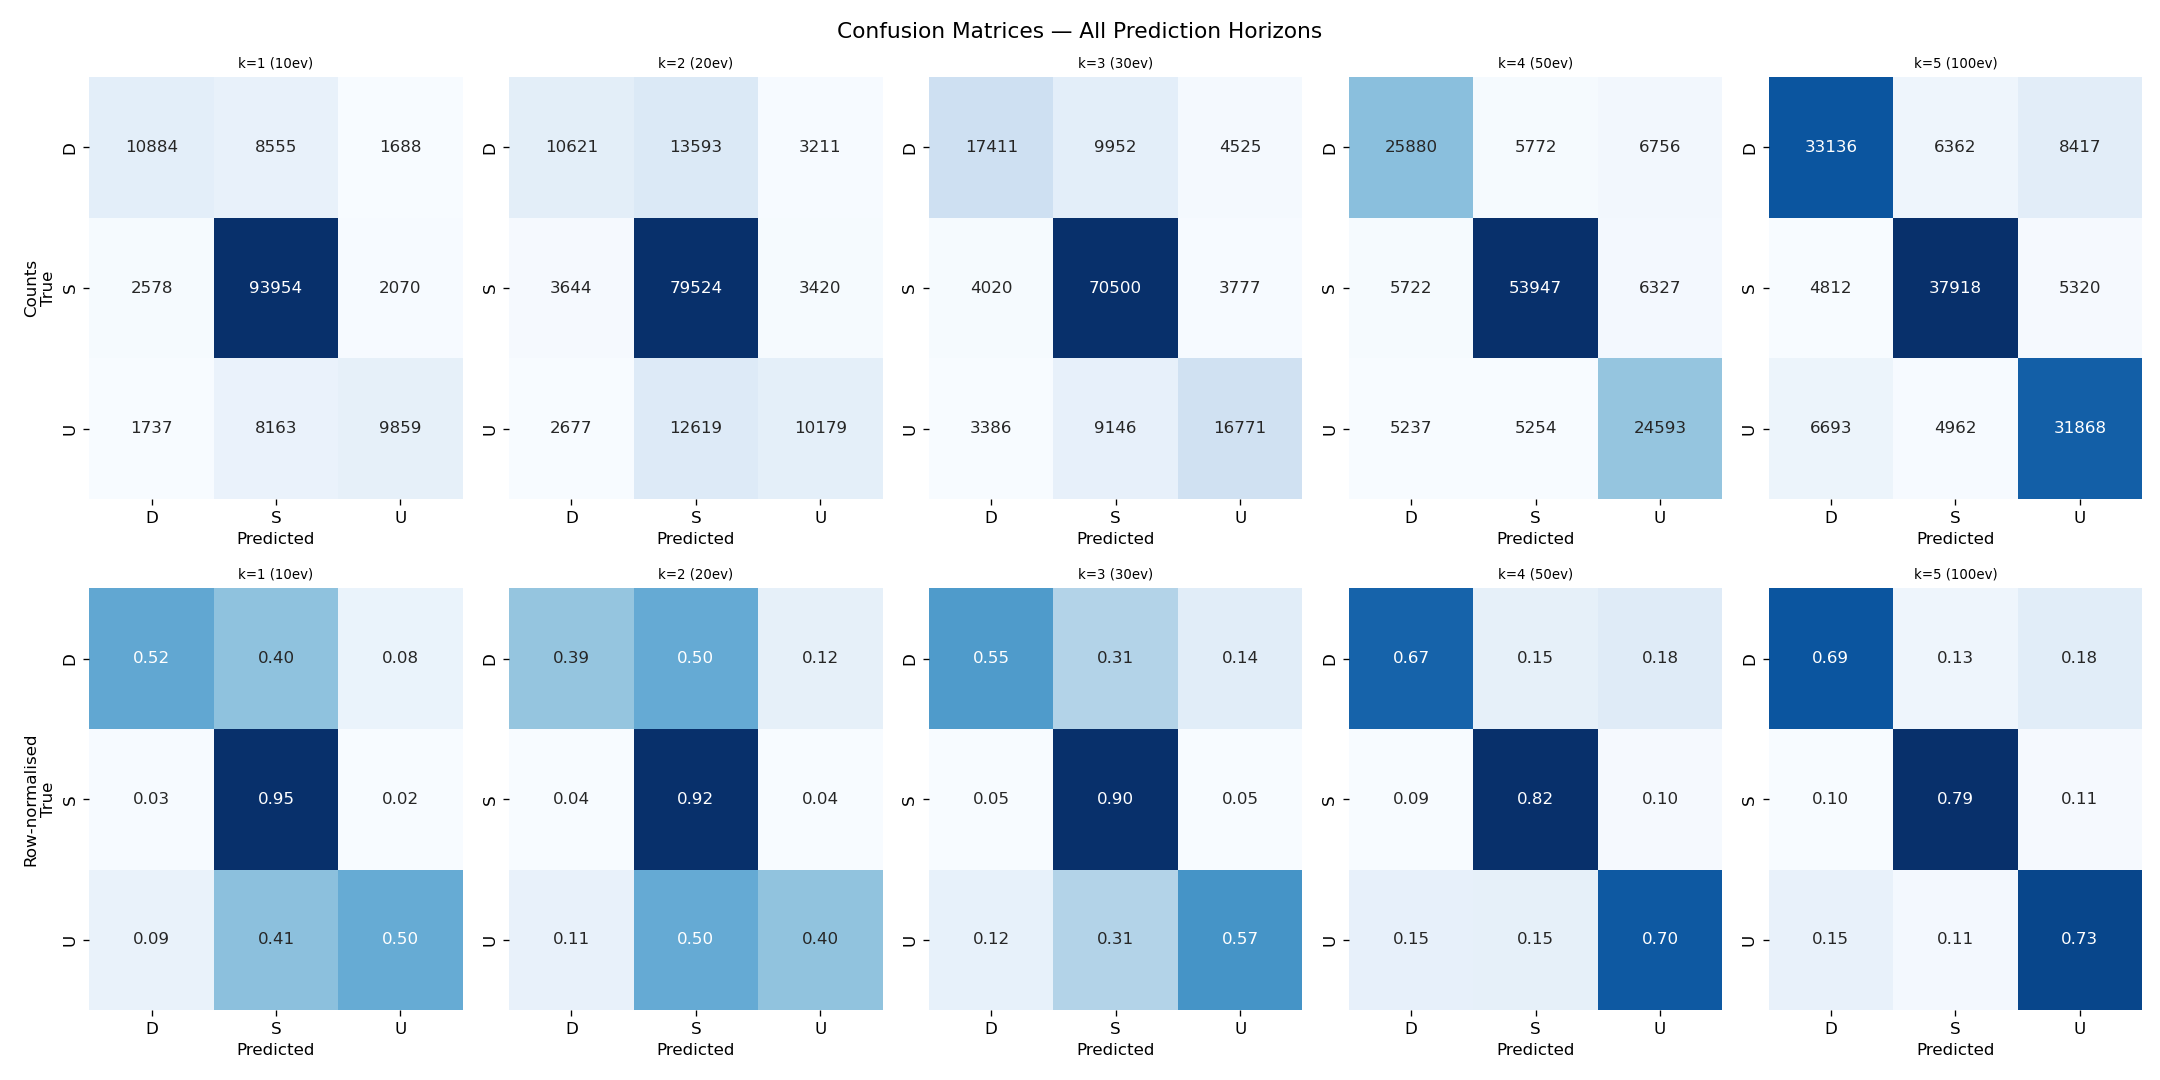

In [7]:
display(Image(os.path.join(RESULT_DIR, 'all_cm_summary.png')))


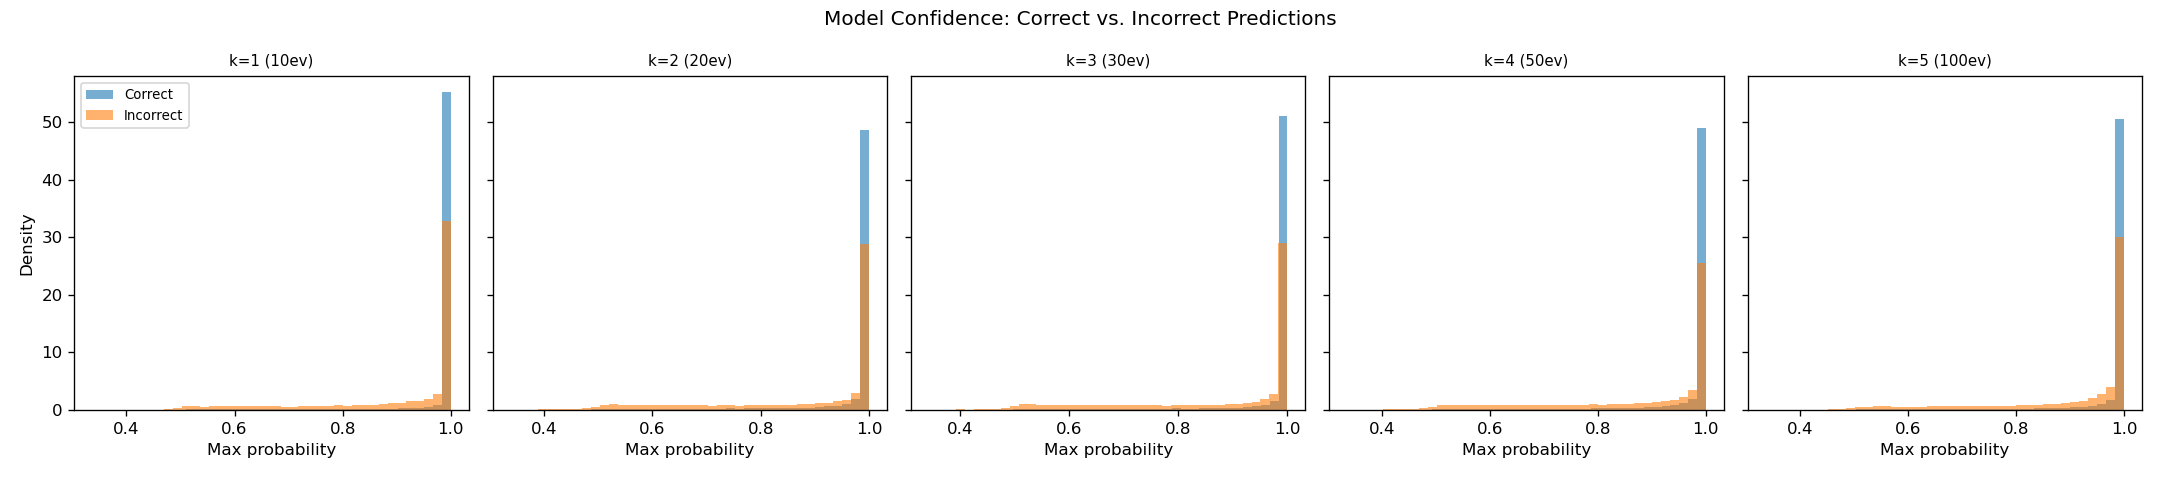

In [8]:
display(Image(os.path.join(RESULT_DIR, 'confidence_dist.png')))


### Per-horizon training curves
These curves come from the GPU training script and are loaded from `results/loss_k*.png`.


In [9]:
for k in range(5):
    print(f'Loss curve for k={k+1}')
    display(Image(os.path.join(RESULT_DIR, f'loss_k{k}.png')))


Loss curve for k=1


FileNotFoundError: No such file or directory: '/ocean/projects/mth250011p/xxiao7/DeepLOB/results/loss_k0.png'

FileNotFoundError: No such file or directory: '/ocean/projects/mth250011p/xxiao7/DeepLOB/results/loss_k0.png'

<IPython.core.display.Image object>

Loss curve for k=2


...

<IPython.core.display.Image object>

Loss curve for k=5


FileNotFoundError: No such file or directory: '/ocean/projects/mth250011p/xxiao7/DeepLOB/results/loss_k4.png'

FileNotFoundError: No such file or directory: '/ocean/projects/mth250011p/xxiao7/DeepLOB/results/loss_k4.png'

<IPython.core.display.Image object>

## 6. Engineered-feature statistical tests (u2–u9)

This section corresponds to the **added manual-factor analysis** on top of the original paper workflow.

Pipeline:
1. Newey-West full-sample predictability test
2. Rolling-window stability test
3. Monotonicity and Rank-IC evaluation
4. FDR (Benjamini-Hochberg) qualification


In [10]:
fp = os.path.join(RESULT_DIR, 'feature_predictability.csv')
roll = os.path.join(RESULT_DIR, 'rolling_stability.csv')
qual = os.path.join(RESULT_DIR, 'qualified_factors.csv')
if os.path.exists(fp):
    df_fp = pd.read_csv(fp)
    display(df_fp.sort_values('p_NW').head(15))
if os.path.exists(roll):
    df_roll = pd.read_csv(roll)
    display(df_roll.sort_values(['Sig ratio','Mean |t_NW|'], ascending=False).head(15))
if os.path.exists(qual):
    df_qual = pd.read_csv(qual)
    display(df_qual)


,Set,Description,Feature #,Data row,beta,t_NW,p_NW,sig_05,sig_001
46,u6,Price & Volume Derivatives,1,86,0.018467,11.285238,1.583877e-29,True,True
48,u6,Price & Volume Derivatives,3,88,0.022054,10.835288,2.382883e-27,True,True
47,u6,Price & Volume Derivatives,2,87,0.005929,8.017538,1.084505e-15,True,True
52,u6,Price & Volume Derivatives,7,92,0.016483,7.242243,4.428724e-13,True,True
55,u6,Price & Volume Derivatives,10,95,0.002469,7.172812,7.372064e-13,True,True
51,u6,Price & Volume Derivatives,6,91,0.003191,6.621797,3.557337e-11,True,True
68,u6,Price & Volume Derivatives,23,108,0.005319,6.540626,6.140581e-11,True,True
76,u6,Price & Volume Derivatives,31,116,0.003251,6.454897,1.085346e-10,True,True
72,u6,Price & Volume Derivatives,27,112,0.004032,6.453896,1.092536e-10,True,True
64,u6,Price & Volume Derivatives,19,104,0.007153,6.373906,1.846648e-10,True,True


,Set,Description,Feature #,Data row,beta_full,t_NW_full,p_NW_full,N windows,Sig windows,Sig ratio,Mean |t_NW|
4,u6,Price & Volume Derivatives,1,86,0.018467,11.285238,1.583877e-29,37,33,0.892,9.222
6,u6,Price & Volume Derivatives,3,88,0.022054,10.835288,2.382883e-27,37,33,0.892,9.197
9,u6,Price & Volume Derivatives,7,92,0.016483,7.242243,4.428724e-13,37,32,0.865,9.126
21,u6,Price & Volume Derivatives,33,118,0.001217,3.208624,1.333922e-03,37,32,0.865,6.104
14,u6,Price & Volume Derivatives,17,102,0.003741,3.934936,8.324645e-05,37,30,0.811,6.694
10,u6,Price & Volume Derivatives,8,93,-0.008885,-2.211793,2.698211e-02,37,30,0.811,3.491
7,u6,Price & Volume Derivatives,5,90,0.010358,4.737577,2.164337e-06,37,29,0.784,8.101
23,u6,Price & Volume Derivatives,37,122,0.000933,2.361126,1.822047e-02,37,29,0.784,5.204
5,u6,Price & Volume Derivatives,2,87,0.005929,8.017538,1.084505e-15,37,29,0.784,3.730
12,u6,Price & Volume Derivatives,11,96,0.010760,4.609600,4.036883e-06,37,28,0.757,8.669


,Set,Description,Feature #,Data row,beta,t_NW,p_NW,sig_05,sig_001,BH_pass,Sig ratio,Mean |t_NW|
0,u3,Price Differences,11,70,-0.013217,-3.279314,1.040773e-03,True,False,True,0.757,4.099
1,u6,Price & Volume Derivatives,1,86,0.018467,11.285238,1.583877e-29,True,True,True,0.892,9.222
2,u6,Price & Volume Derivatives,2,87,0.005929,8.017538,1.084505e-15,True,True,True,0.784,3.730
3,u6,Price & Volume Derivatives,3,88,0.022054,10.835288,2.382883e-27,True,True,True,0.892,9.197
4,u6,Price & Volume Derivatives,5,90,0.010358,4.737577,2.164337e-06,True,True,True,0.784,8.101
5,u6,Price & Volume Derivatives,6,91,0.003191,6.621797,3.557337e-11,True,True,True,0.595,2.756
6,u6,Price & Volume Derivatives,7,92,0.016483,7.242243,4.428724e-13,True,True,True,0.865,9.126
7,u6,Price & Volume Derivatives,10,95,0.002469,7.172812,7.372064e-13,True,True,True,0.730,2.495
8,u6,Price & Volume Derivatives,11,96,0.010760,4.609600,4.036883e-06,True,True,True,0.757,8.669
9,u6,Price & Volume Derivatives,15,100,0.009152,5.949564,2.692940e-09,True,True,True,0.757,8.575


feature_nw_ttest.png


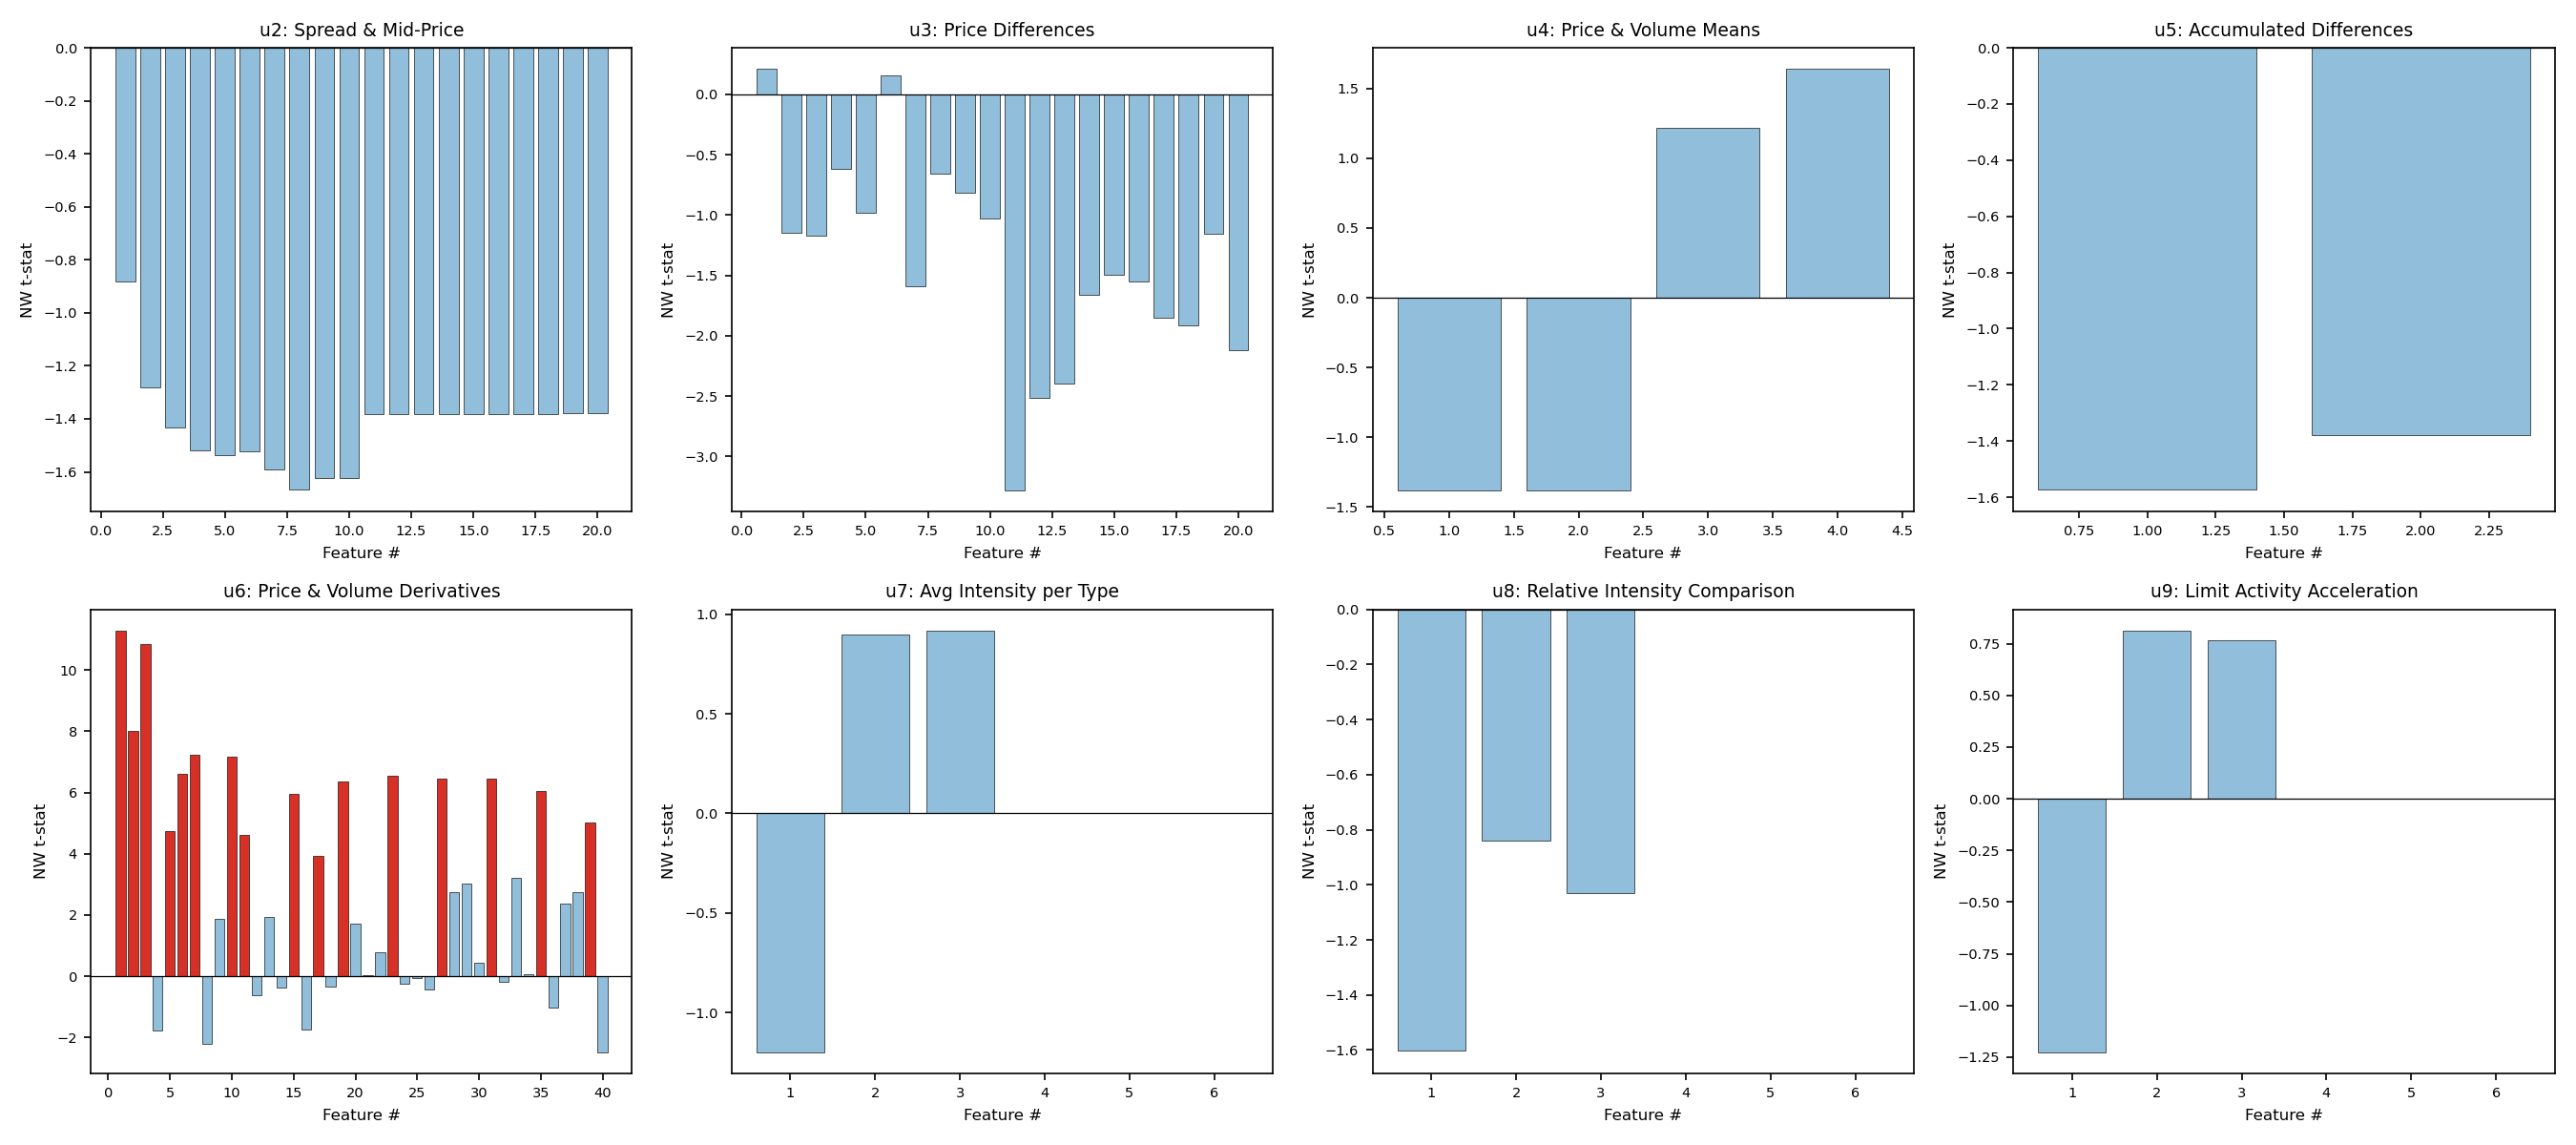

rolling_ttest.png


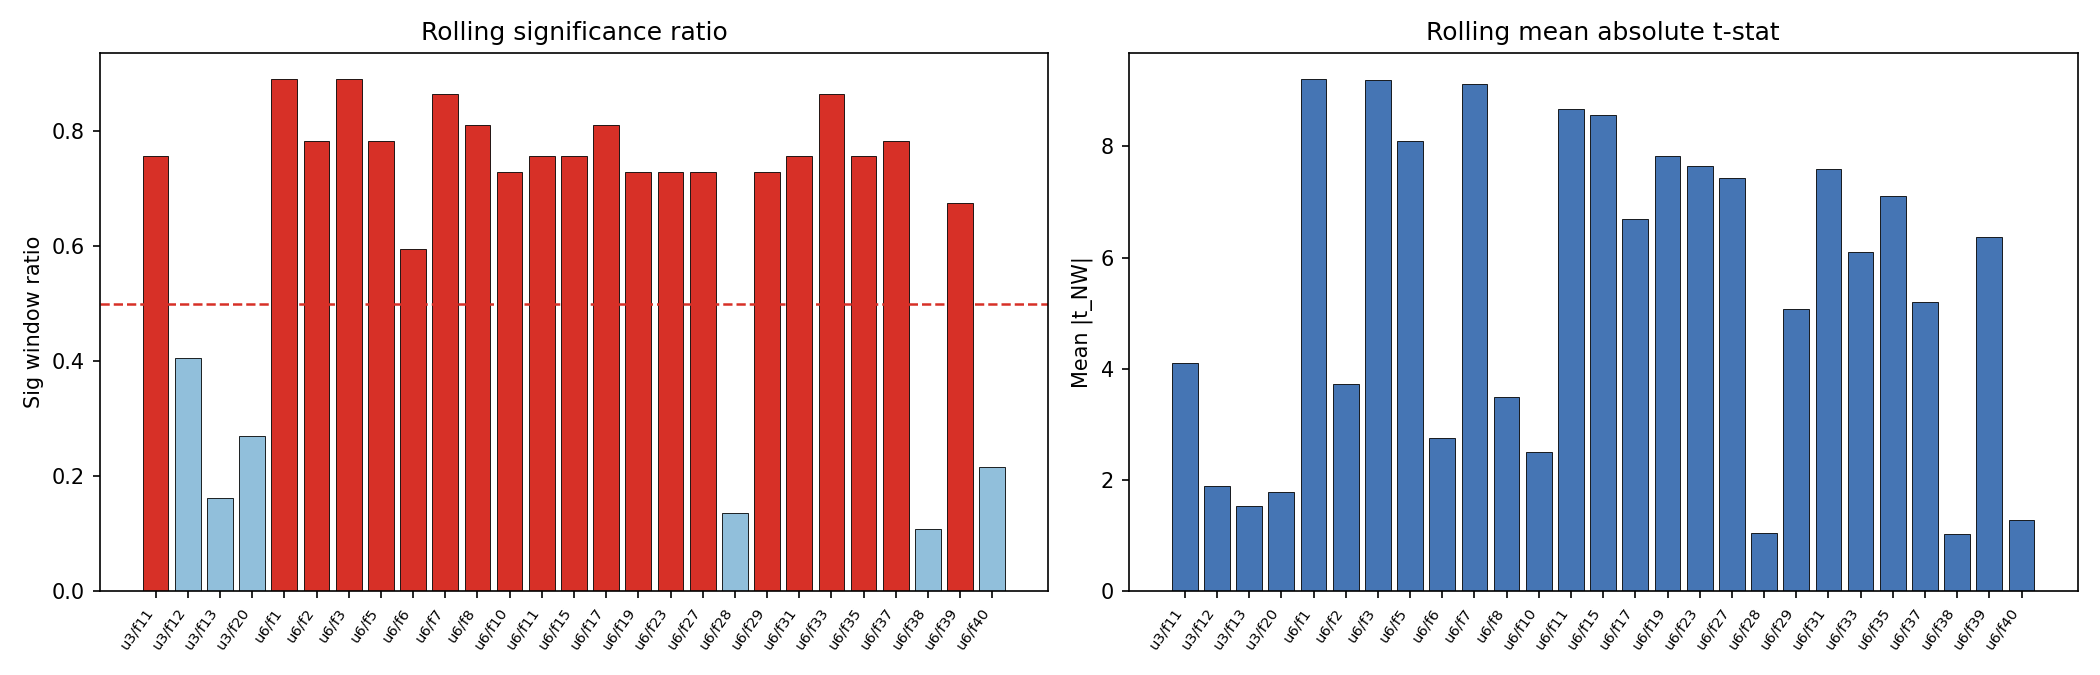

factor_monotonicity.png


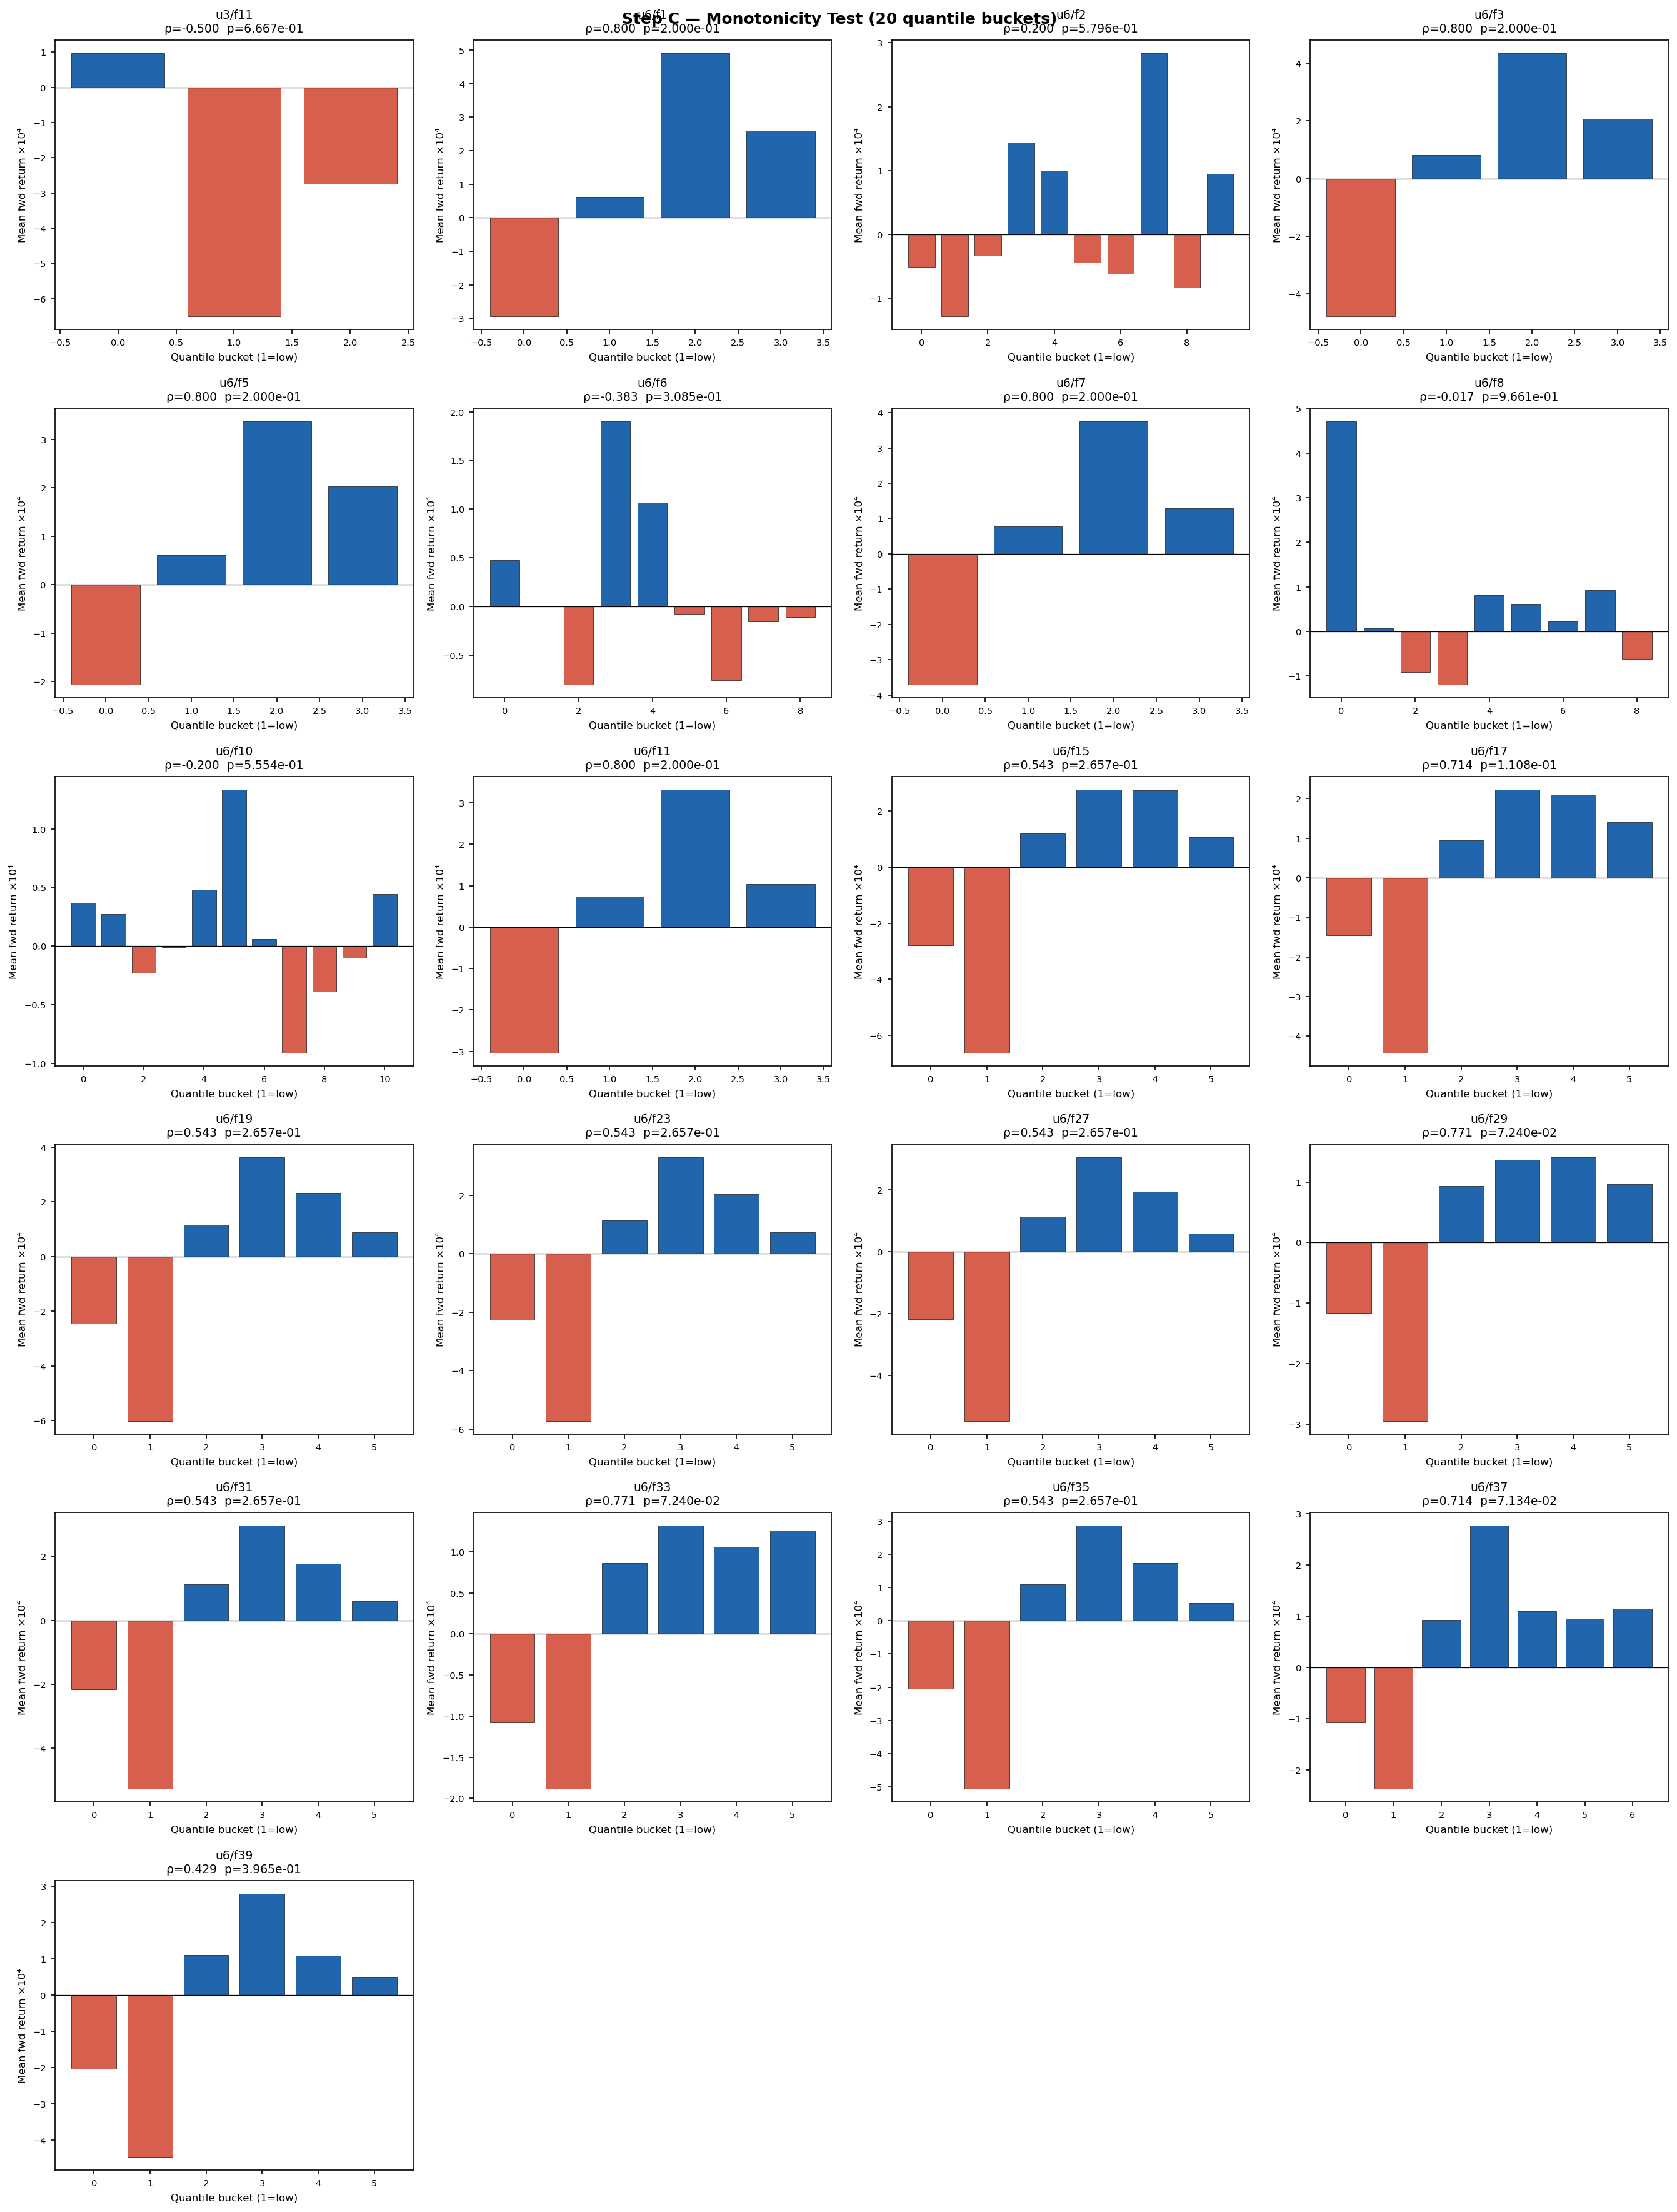

factor_rank_ic.png


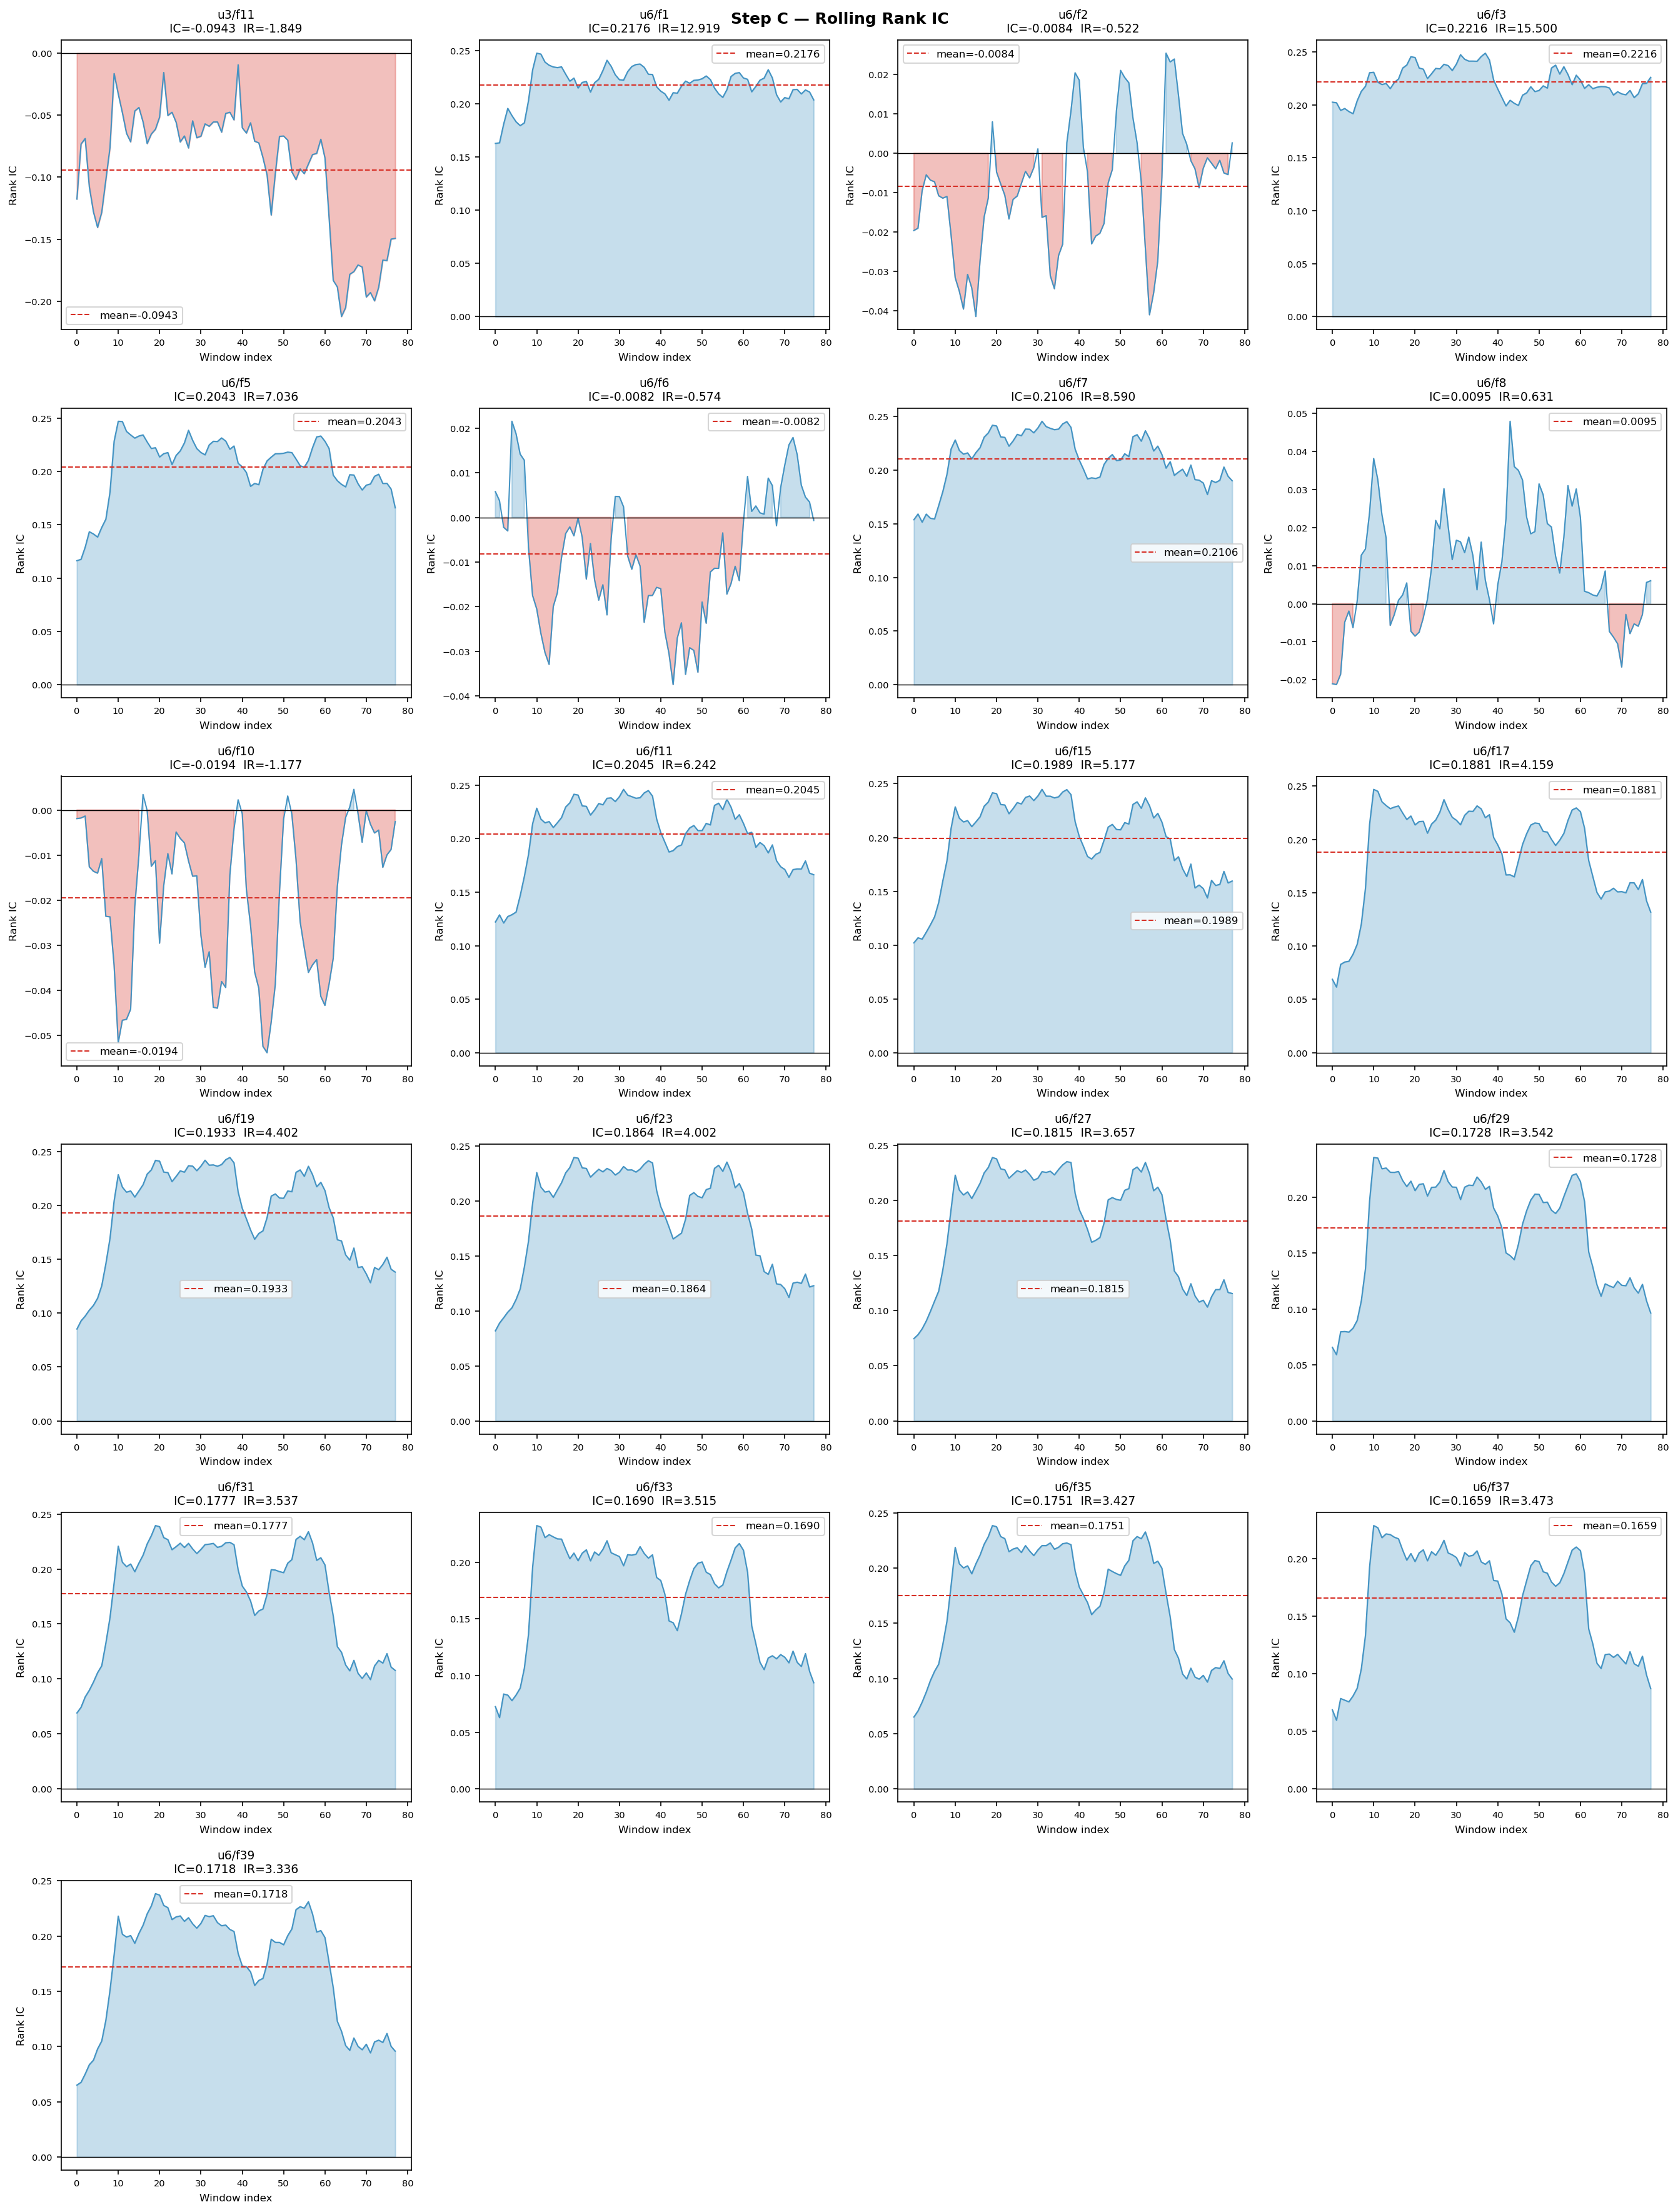

qualified_monotonicity.png


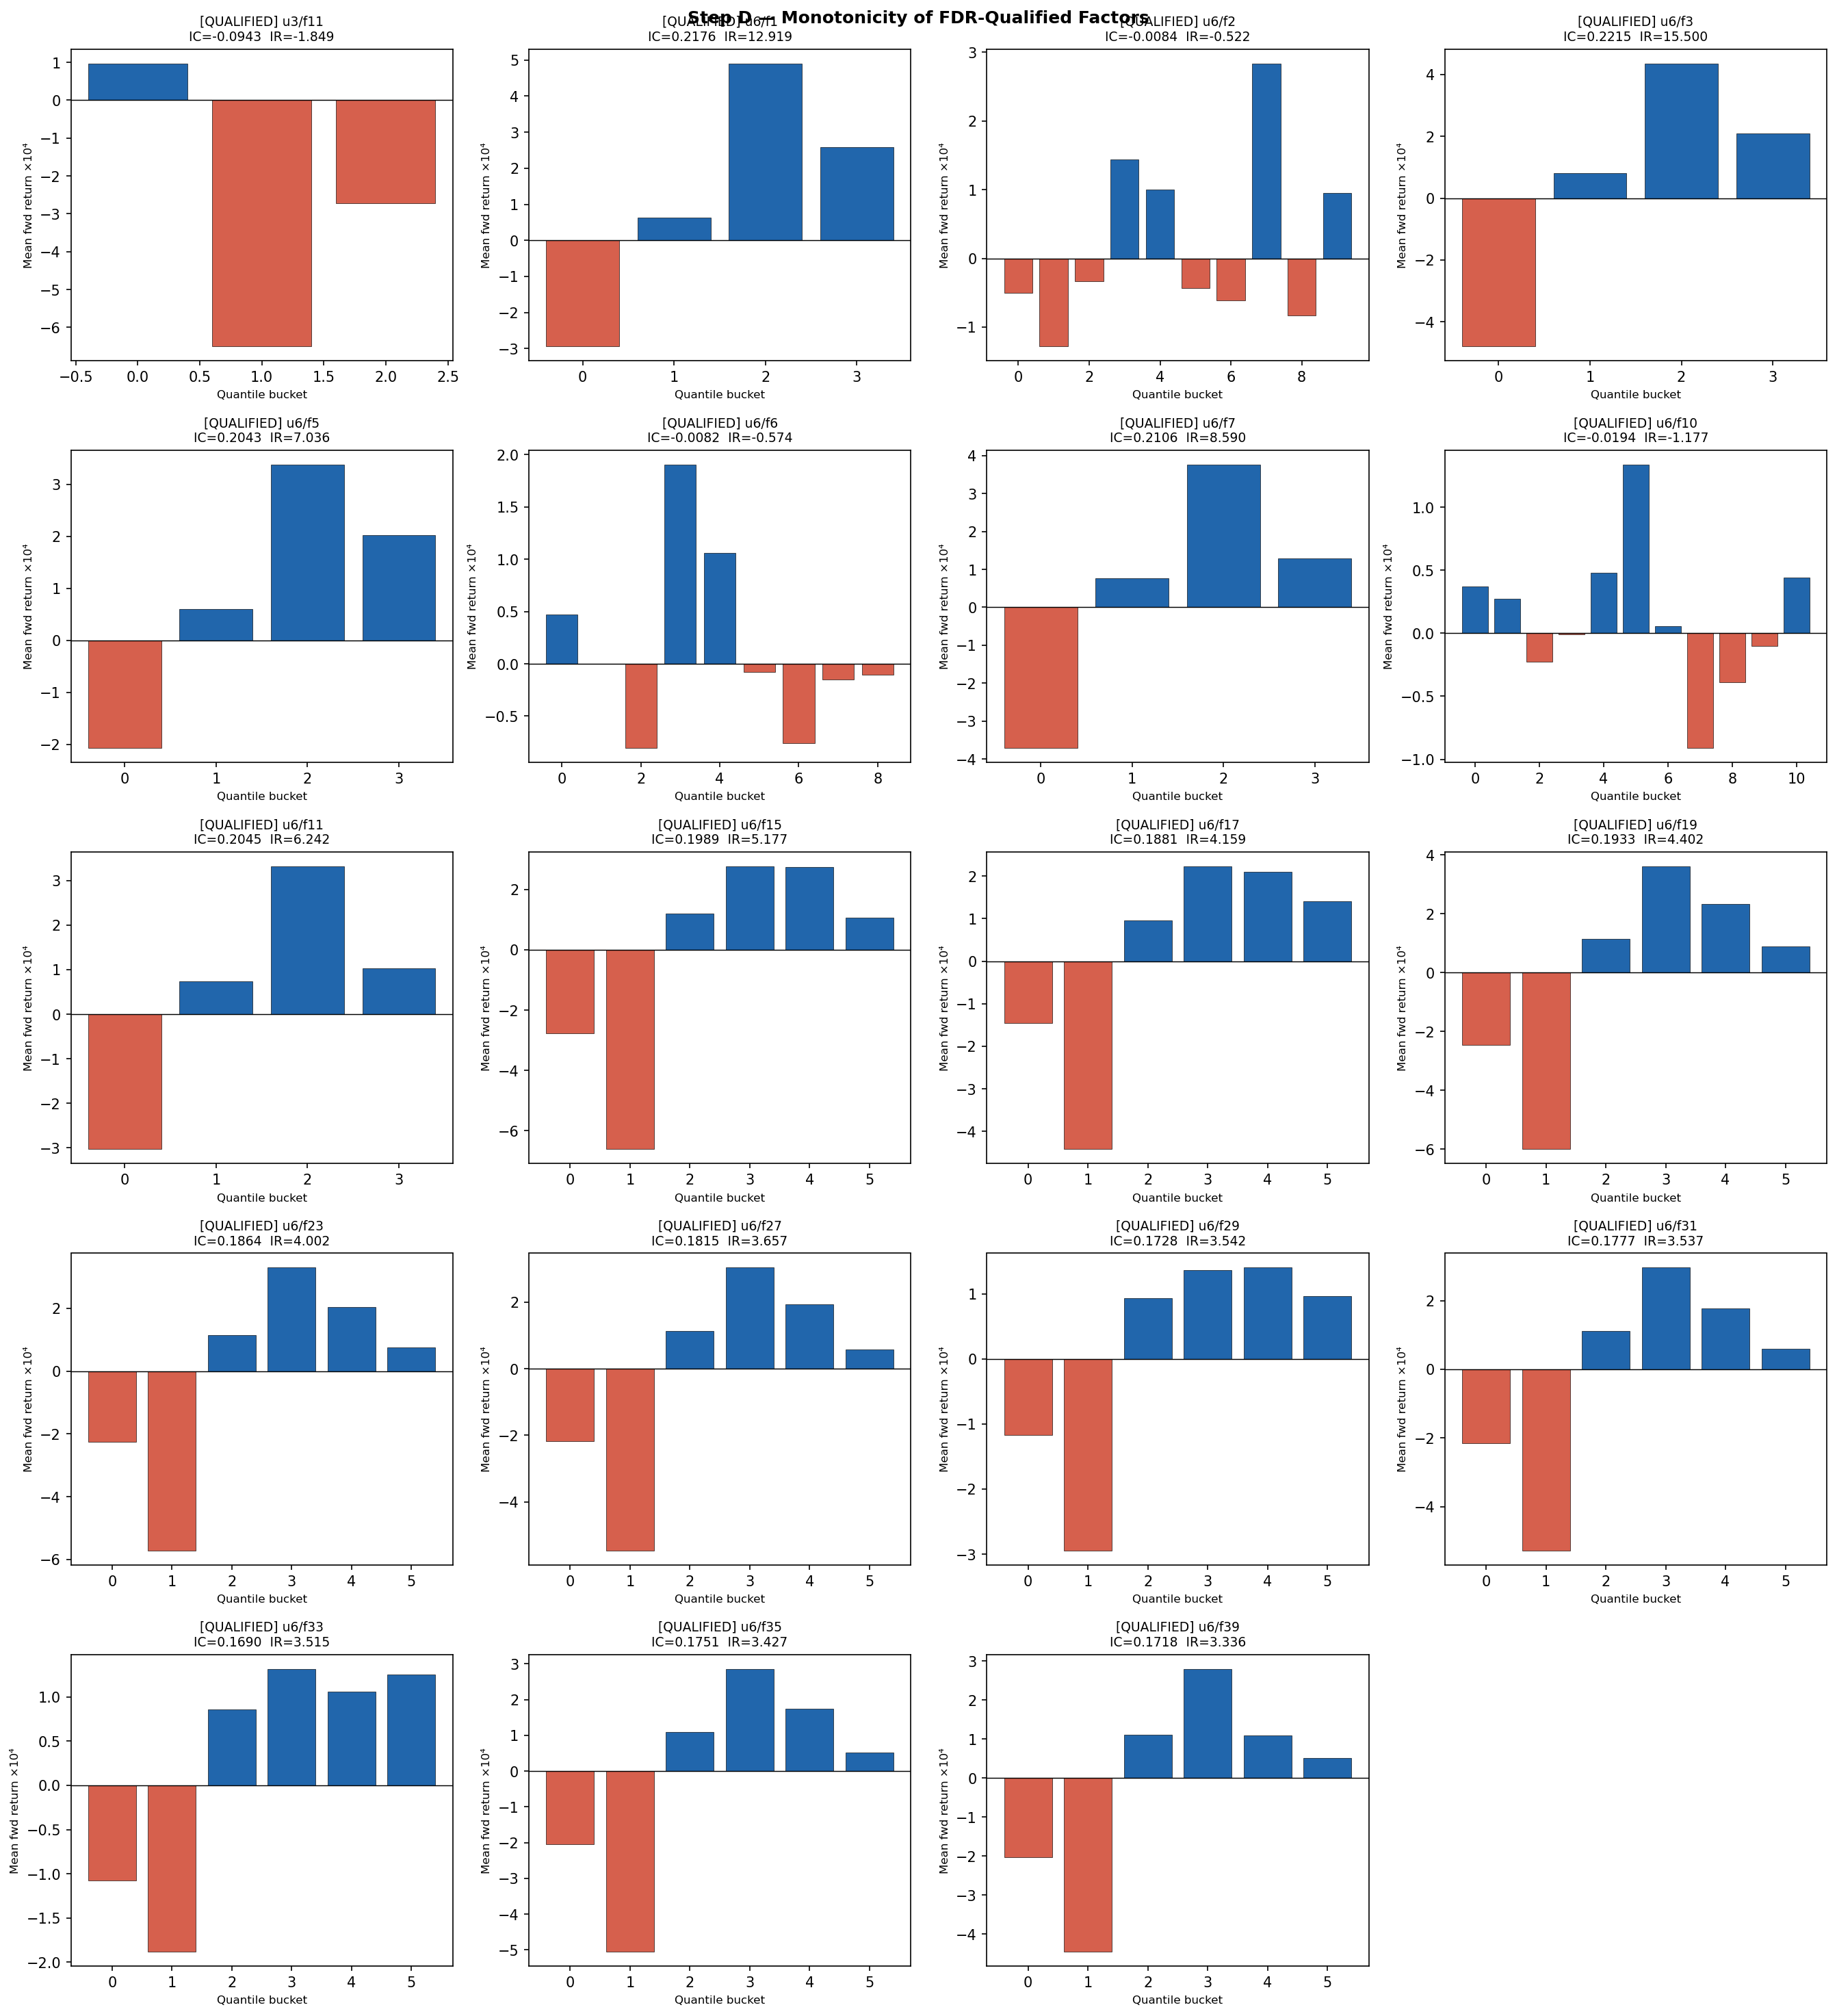

In [11]:
for name in ['feature_nw_ttest.png', 'rolling_ttest.png', 'factor_monotonicity.png', 'factor_rank_ic.png', 'qualified_monotonicity.png']:
    path = os.path.join(RESULT_DIR, name)
    if os.path.exists(path):
        print(name)
        display(Image(path))


## 7. Baseline models vs. DeepLOB

The baseline block compares DeepLOB against:
- **Ridge Logistic Regression** on qualified engineered factors
- **MLP (64-32)** on the same qualified factors

This section is designed to answer whether the manual-factor pipeline plus standard baselines can match the full DeepLOB architecture.


,Model,Accuracy,Cohen κ,MCC,F1-Down,F1-Stat,F1-Up,F1-Weighted,Sharpe-like
0,Ridge Logistic Regression,0.709937,0.004462,0.031528,0.002145,0.830545,0.007999,0.590876,0.001678
1,MLP (64-32),0.714700,0.143450,0.187571,0.140161,0.840188,0.169665,0.641081,0.017958
2,DeepLOB,0.822300,0.565300,0.578400,0.599200,0.897900,0.590800,0.809200,NaN


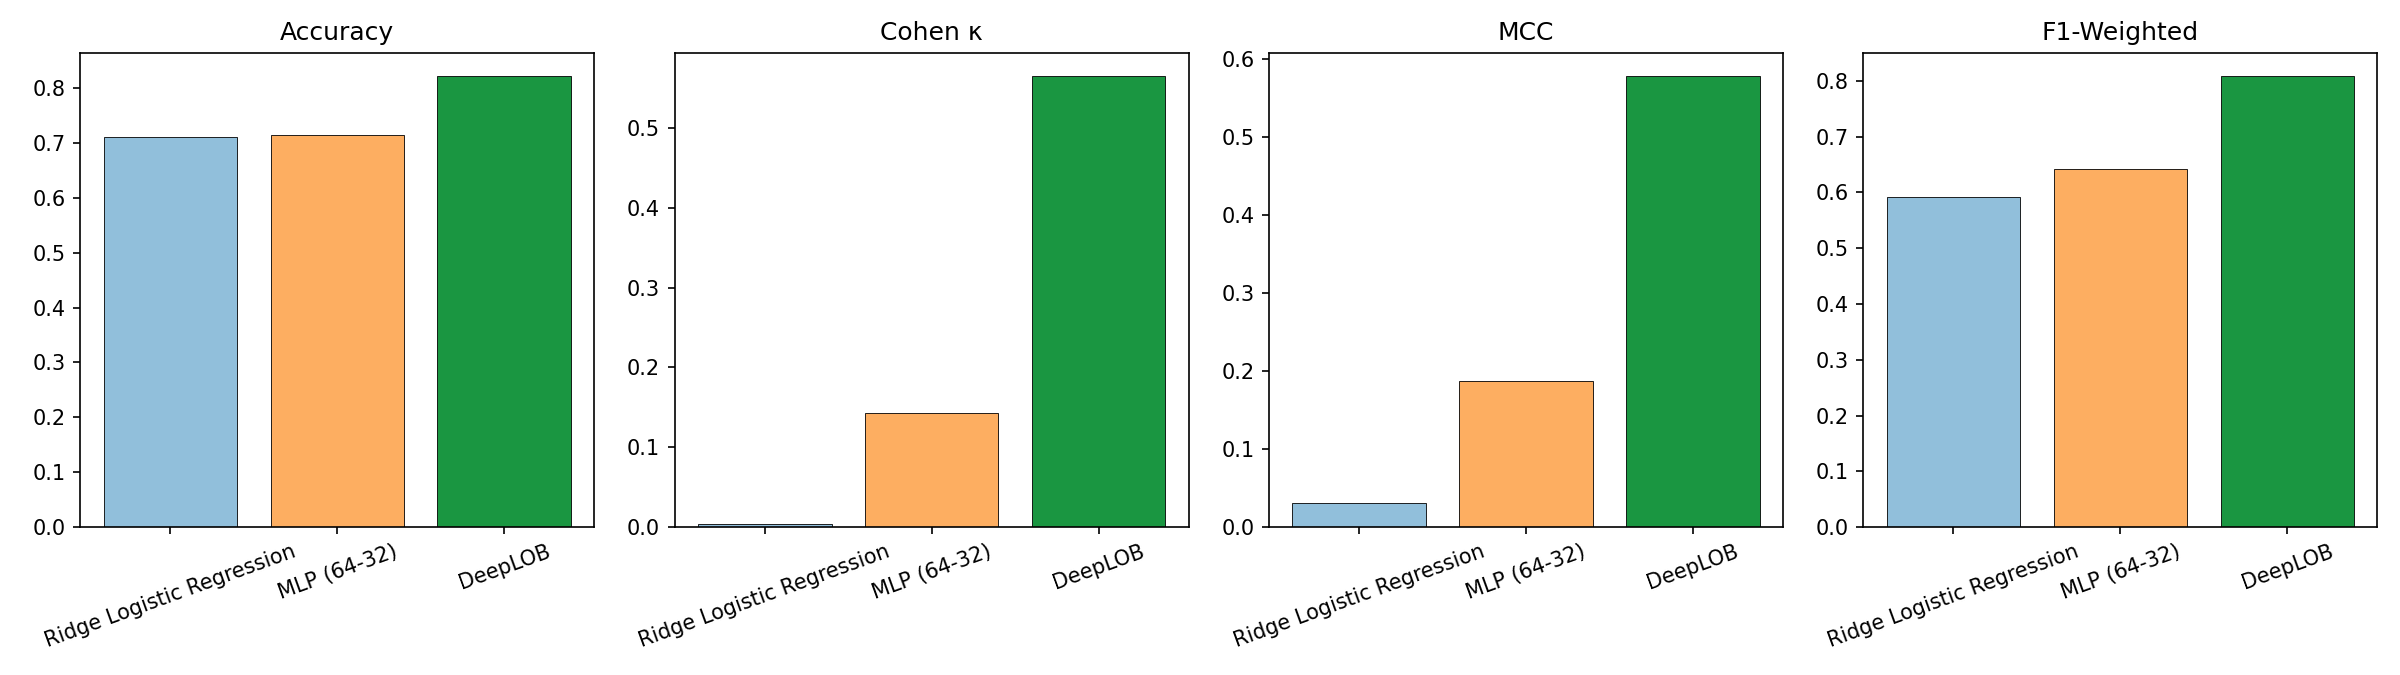

In [12]:
base_csv = os.path.join(RESULT_DIR, 'baseline_model_comparison.csv')
base_png = os.path.join(RESULT_DIR, 'baseline_comparison.png')
if os.path.exists(base_csv):
    df_base = pd.read_csv(base_csv)
    display(df_base)
else:
    print('baseline_model_comparison.csv not generated yet. Run submit_analysis.sh.')
if os.path.exists(base_png):
    display(Image(base_png))


## 8. Statistical tests and strategy-style evaluation

In [13]:
stats_csv = os.path.join(RESULT_DIR, 'statistical_tests.csv')
if os.path.exists(stats_csv):
    display(pd.read_csv(stats_csv))


,Horizon,Test,Class,Statistic,p_value,Significant
0,k=1 (10ev),T1-mean-prob,Down,-283.662900,0.000000e+00,True
1,k=1 (10ev),T1-mean-prob,Stationary,442.686404,0.000000e+00,True
2,k=1 (10ev),T1-mean-prob,Up,-313.146593,0.000000e+00,True
3,k=1 (10ev),T2-welch,Down,569.742620,0.000000e+00,True
4,k=1 (10ev),T2-welch,Stationary,366.317884,0.000000e+00,True
5,k=1 (10ev),T2-welch,Up,572.621256,0.000000e+00,True
6,k=1 (10ev),T3-precision-z,Down,104.657818,0.000000e+00,True
7,k=1 (10ev),T3-precision-z,Stationary,478.989749,0.000000e+00,True
8,k=1 (10ev),T3-precision-z,Up,101.989985,0.000000e+00,True
9,k=1 (10ev),T4-KS,all,0.442845,0.000000e+00,True


,Horizon,Events ahead,Mean daily pnl,Std daily pnl,Sharpe-like,t-stat,p-value
0,k=1,10,0.010956,0.444205,0.024665,0.411243,0.681211
1,k=2,20,-0.041931,0.973104,-0.043089,-0.718445,0.473086
2,k=3,30,0.004565,0.947658,0.004817,0.080322,0.936039
3,k=4,50,-0.010902,2.008760,-0.005427,-0.090487,0.927966
4,k=5,100,-0.301983,2.763766,-0.109265,-1.821814,0.069558


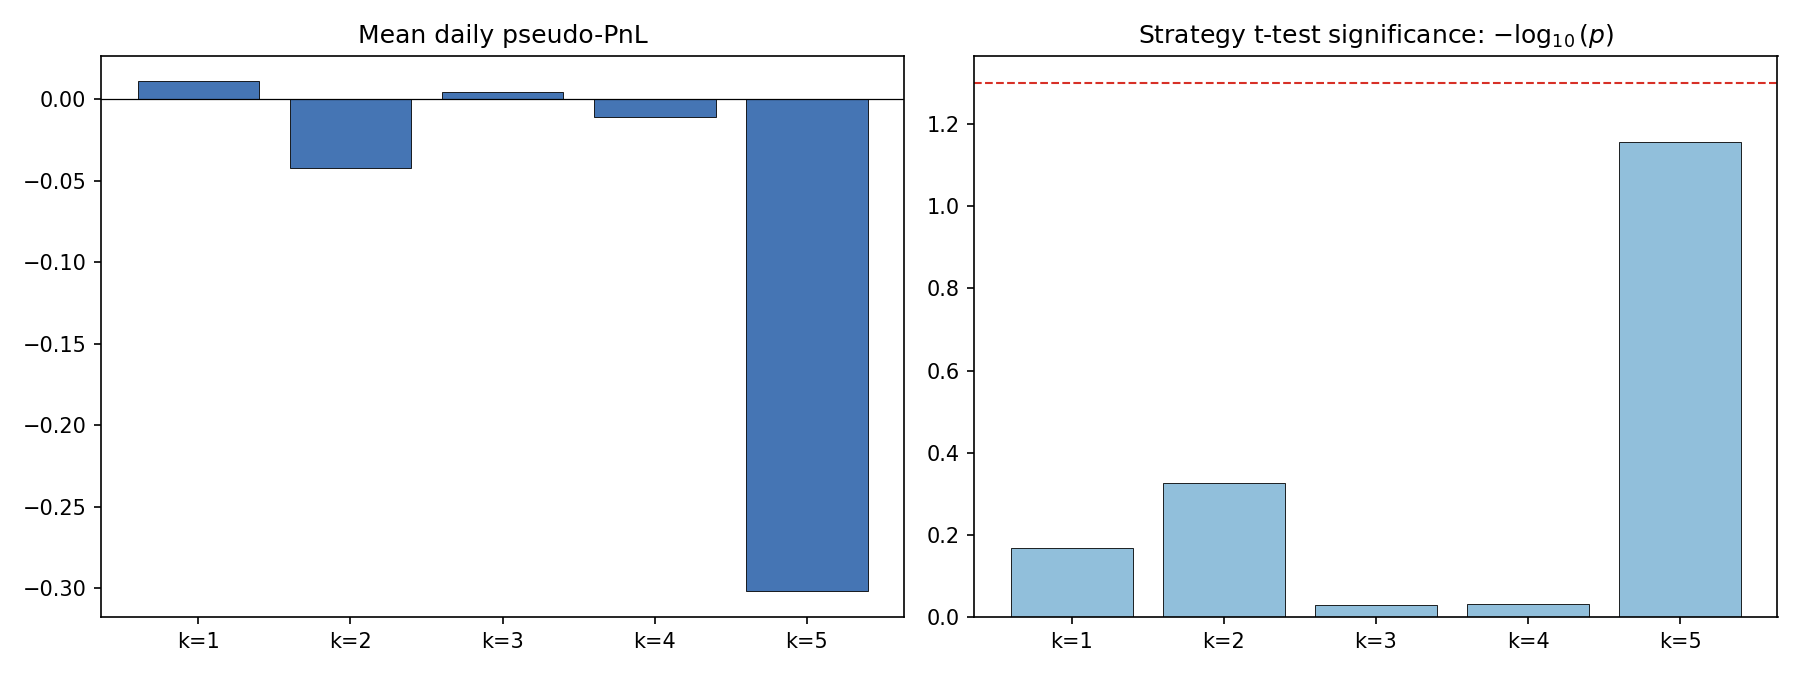

In [14]:
trade_csv = os.path.join(RESULT_DIR, 'trading_strategy_stats.csv')
if os.path.exists(trade_csv):
    display(pd.read_csv(trade_csv))
else:
    print('trading_strategy_stats.csv not generated yet. Run submit_analysis.sh.')
if os.path.exists(os.path.join(RESULT_DIR, 'trading_profit_ttest.png')):
    display(Image(os.path.join(RESULT_DIR, 'trading_profit_ttest.png')))


## 9. Interpretation summary

In [15]:
perf = pd.read_csv(os.path.join(RESULT_DIR, 'performance_summary.csv'))
best = perf.sort_values('Accuracy', ascending=False).iloc[0]
print('Best DeepLOB horizon:')
print(best.to_string())

if os.path.exists(os.path.join(RESULT_DIR, 'baseline_model_comparison.csv')):
    df_base = pd.read_csv(os.path.join(RESULT_DIR, 'baseline_model_comparison.csv'))
    print('\nBaseline comparison:')
    print(df_base.to_string(index=False))


Best DeepLOB horizon:
Horizon        k=1 (10 ev)
Accuracy            0.8223
Cohen κ             0.5653
MCC                 0.5784
F1-Down             0.5992
F1-Stat             0.8979
F1-Up               0.5908
F1-Weighted         0.8092

Baseline comparison:
                    Model  Accuracy  Cohen κ      MCC  F1-Down  F1-Stat    F1-Up  F1-Weighted  Sharpe-like
Ridge Logistic Regression  0.709937 0.004462 0.031528 0.002145 0.830545 0.007999     0.590876     0.001678
              MLP (64-32)  0.714700 0.143450 0.187571 0.140161 0.840188 0.169665     0.641081     0.017958
                  DeepLOB  0.822300 0.565300 0.578400 0.599200 0.897900 0.590800     0.809200          NaN
